# ChestMNIST DINOv2 Skeleton Demo

This notebook checks the shared data, model, training, evaluation, and XAI interfaces on a tiny automatically downloaded ChestMNIST subset.

In [29]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

requirements_file = project_root / "requirements.txt"
print("Python:", sys.executable)
print("Project root:", project_root)
print("Requirements:", requirements_file)

Python: c:\Users\vasko\anaconda3\envs\cumid\python.exe
Project root: c:\Users\vasko\Downloads\xai\project
Requirements: c:\Users\vasko\Downloads\xai\project\requirements.txt


If the imports below fail with `ModuleNotFoundError`, uncomment and run the next cell once in this notebook kernel, then restart the kernel.

In [30]:
# %pip install -r "{requirements_file}"

In [31]:
import pandas as pd
import torch

from src.data import get_small_data
from src.model import get_dino_model, get_probs, count_trainable_params, count_total_params
from src.train import train_model
from src.eval import classification_metrics
from src.xai import make_heatmap, show_heatmap

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [32]:
epochs = 20
batch_size = 20
learning_rate = 1e-3

n_train = 1000
n_val = 300

In [33]:
train_loader, val_loader, class_names = get_small_data(
    n_train=n_train,
    n_val=n_val,
    batch_size=batch_size,
)

batch = next(iter(train_loader))
print("images:", batch["images"].shape)
print("labels:", batch["labels"].shape)
print("ids:", batch["ids"][:3])
print("classes:", class_names)

Using downloaded and verified file: C:\Users\vasko\.medmnist\chestmnist.npz
Using downloaded and verified file: C:\Users\vasko\.medmnist\chestmnist.npz
images: torch.Size([20, 3, 224, 224])
labels: torch.Size([20, 14])
ids: ['train_82', 'train_49', 'train_141']
classes: ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration', 'mass', 'nodule', 'pneumonia', 'pneumothorax', 'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']


In [34]:
model = get_dino_model(num_classes=len(class_names)).to(device)

print("total params:", f"{count_total_params(model):,}")
print("trainable params:", f"{count_trainable_params(model):,}")

total params: 22,061,966
trainable params: 5,390


In [35]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    lr=learning_rate,
)

pd.DataFrame(history).drop(columns=["val_auc_per_class"])

Epoch 1/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/20 | train_loss=0.2526 | val_loss=0.1879 | val_mean_auc=0.5492


Epoch 2/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2/20 | train_loss=0.1888 | val_loss=0.1837 | val_mean_auc=0.5864


Epoch 3/20:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch 19/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 19/20 | train_loss=0.1375 | val_loss=0.1887 | val_mean_auc=0.6333


Epoch 20/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 20/20 | train_loss=0.1356 | val_loss=0.1878 | val_mean_auc=0.6305


,epoch,train_loss,val_loss,val_mean_auc
0,1,0.252552,0.187925,0.549212
1,2,0.188830,0.183704,0.586431
2,3,0.180961,0.177760,0.604571
3,4,0.174973,0.175203,0.616555
4,5,0.170798,0.177026,0.629387
5,6,0.166435,0.177350,0.632771
6,7,0.163031,0.181799,0.636658
7,8,0.158950,0.177432,0.639512
8,9,0.158612,0.177635,0.637444
9,10,0.154929,0.179231,0.641157


In [36]:
probs, labels, ids = get_probs(model, val_loader, device)

print("probs:", probs.shape)
print("labels:", labels.shape)
print("ids:", len(ids))

Predicting:   0%|          | 0/15 [00:00<?, ?it/s]

probs: torch.Size([300, 14])
labels: torch.Size([300, 14])
ids: 300


In [37]:
metrics = classification_metrics(probs, labels)
print(metrics)

{'mean_auc': 0.6304751671119658, 'auc_per_class': [0.6941090909090909, 0.6250609458800584, 0.8543771043771043, 0.6330645161290323, 0.7071406102547971, 0.52687769245177, 0.4653716216216216, 0.645906690140845, 0.5654345654345654, 0.850907029478458, 0.36621315192743764, 0.3445566778900112, 0.6580005360493165, 0.8896321070234113]}


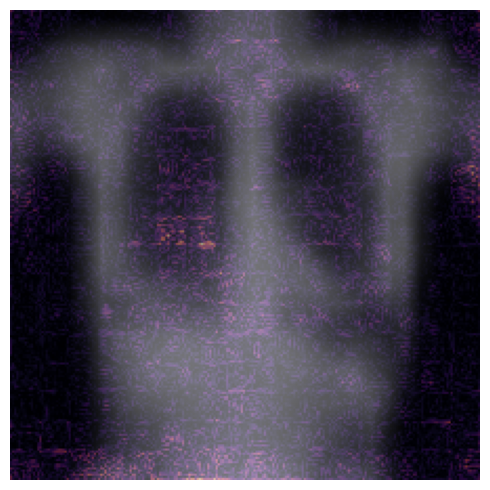

In [38]:
batch = next(iter(val_loader))
image = batch["images"][0]
target_class = 0

heatmap = make_heatmap(model, image, target_class, device)
show_heatmap(image, heatmap)